# Thermodynamic Consistency of Coarse-Grained Models
This notebook analyzes the thermodynamic density fluctuations (via Kirkwood-Buff Theory) of Fine-Grained (FG) and Coarse-Grained (CG) models for ideal and non-ideal mixtures.

Data is sourced from:
> Tripathy, M., Klippenstein, V., & van der Vegt, N. F. (2023). Dynamical coarse-grained models of molecular liquids and their ideal and non-ideal mixtures. *The Journal of Chemical Physics*, 159(9), 094904.

We will calculate the Fluctuation Matrix ($S$-matrix) and visualize the 2D density fluctuation ellipses to verify if the CG models correctly preserve the non-ideal thermodynamics of the atomistic systems.


# Dataset Overview

The data from the Tripathy (2023) paper includes both atomistic (FG) and coarse-grained (CG) simulations of two distinct types of mixtures:

### 1. Ideal Mixtures (`CHX_TCM`)
*   **Components:** Cyclohexane (CHX) and Tetrachloromethane (TCM).
*   **What it means:** These molecules are non-polar and interact similarly with themselves as they do with each other. They mix perfectly and homogeneously.
*   **Thermodynamic Expectation:** Density fluctuations are primarily governed by simple excluded volume (competition for space). We expect regular, predictable shapes for the fluctuation ellipses.
*   **Data Folders:** `CHX_TCM_25-75`, `CHX_TCM_50-50`, `CHX_TCM_75-25` (representing different molar ratios).

### 2. Non-Ideal Mixtures (`ETH_TCM`)
*   **Components:** Ethanol (ETH) and Tetrachloromethane (TCM).
*   **What it means:** Ethanol is polar and heavily forms hydrogen bond networks, whereas TCM is non-polar. This creates a highly non-ideal environment where molecules prefer to cluster with their own kind, leading to local inhomogeneities and micro-phase separations.
*   **Thermodynamic Expectation:** Strong preferential interactions will cause extreme macroscopic correlations ($S_{12}$). We expect the fluctuation ellipses to bulge, widen, or tilt drastically compared to ideal mixtures.
*   **Data Folders:** `ETH_TCM_75-25`.

## FG vs CG 
### 1. Fine-grained (FG)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import sys

# Ensure kb_fluct is in path
sys.path.append('../src')
from kb_fluct import read_xvg, calc_kbi, FluctuationMatrix, EllipseAnalyzer


## Important: Using Exact Simulation Densities
To ensure thermodynamic consistency and avoid negative eigenvalues (which result in unphysical `NaN` eccentricity), we must use the **exact average number density ($\rho = N / \langle V \rangle$)** from the MD simulation, rather than estimating it via ideal mixing rules.

The values below were extracted directly from the FG dataset:
- **Number of molecules ($N$)**: Parsed from `input_files/FG_MD/topol.top`
- **Average Volume ($V$)**: Parsed from the final box vectors in `input_files/FG_MD/conf.gro`

In [2]:
data_root = '../../data/dynamicCG_molmixtures'

# Exact simulation parameters parsed from topol.top and conf.gro
system_params = {
    'CHX_TCM_25-75': {'N1': 500,  'N2': 1500, 'V': 332.673, 'comp1': 'CHX', 'comp2': 'TCM'},
    'CHX_TCM_50-50': {'N1': 1000, 'N2': 1000, 'V': 341.743, 'comp1': 'CHX', 'comp2': 'TCM'},
    'CHX_TCM_75-25': {'N1': 1500, 'N2': 500,  'V': 353.804, 'comp1': 'CHX', 'comp2': 'TCM'},
    'ETH_TCM_75-25': {'N1': 1500, 'N2': 500,  'V': 226.958, 'comp1': 'ETH', 'comp2': 'TCM'}
}

mixtures = list(system_params.keys())

def parse_system_density(system_name):
    params = system_params[system_name]
    rho_1 = params['N1'] / params['V']
    rho_2 = params['N2'] / params['V']
    return rho_1, rho_2, params['comp1'], params['comp2']


/var/folders/yr/nrlvkkq52sl8qmgymrl_yx040000gn/T/ipykernel_59351/2359625780.py:37: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  points = np.random.multivariate_normal([0, 0], S_mat, 50000)


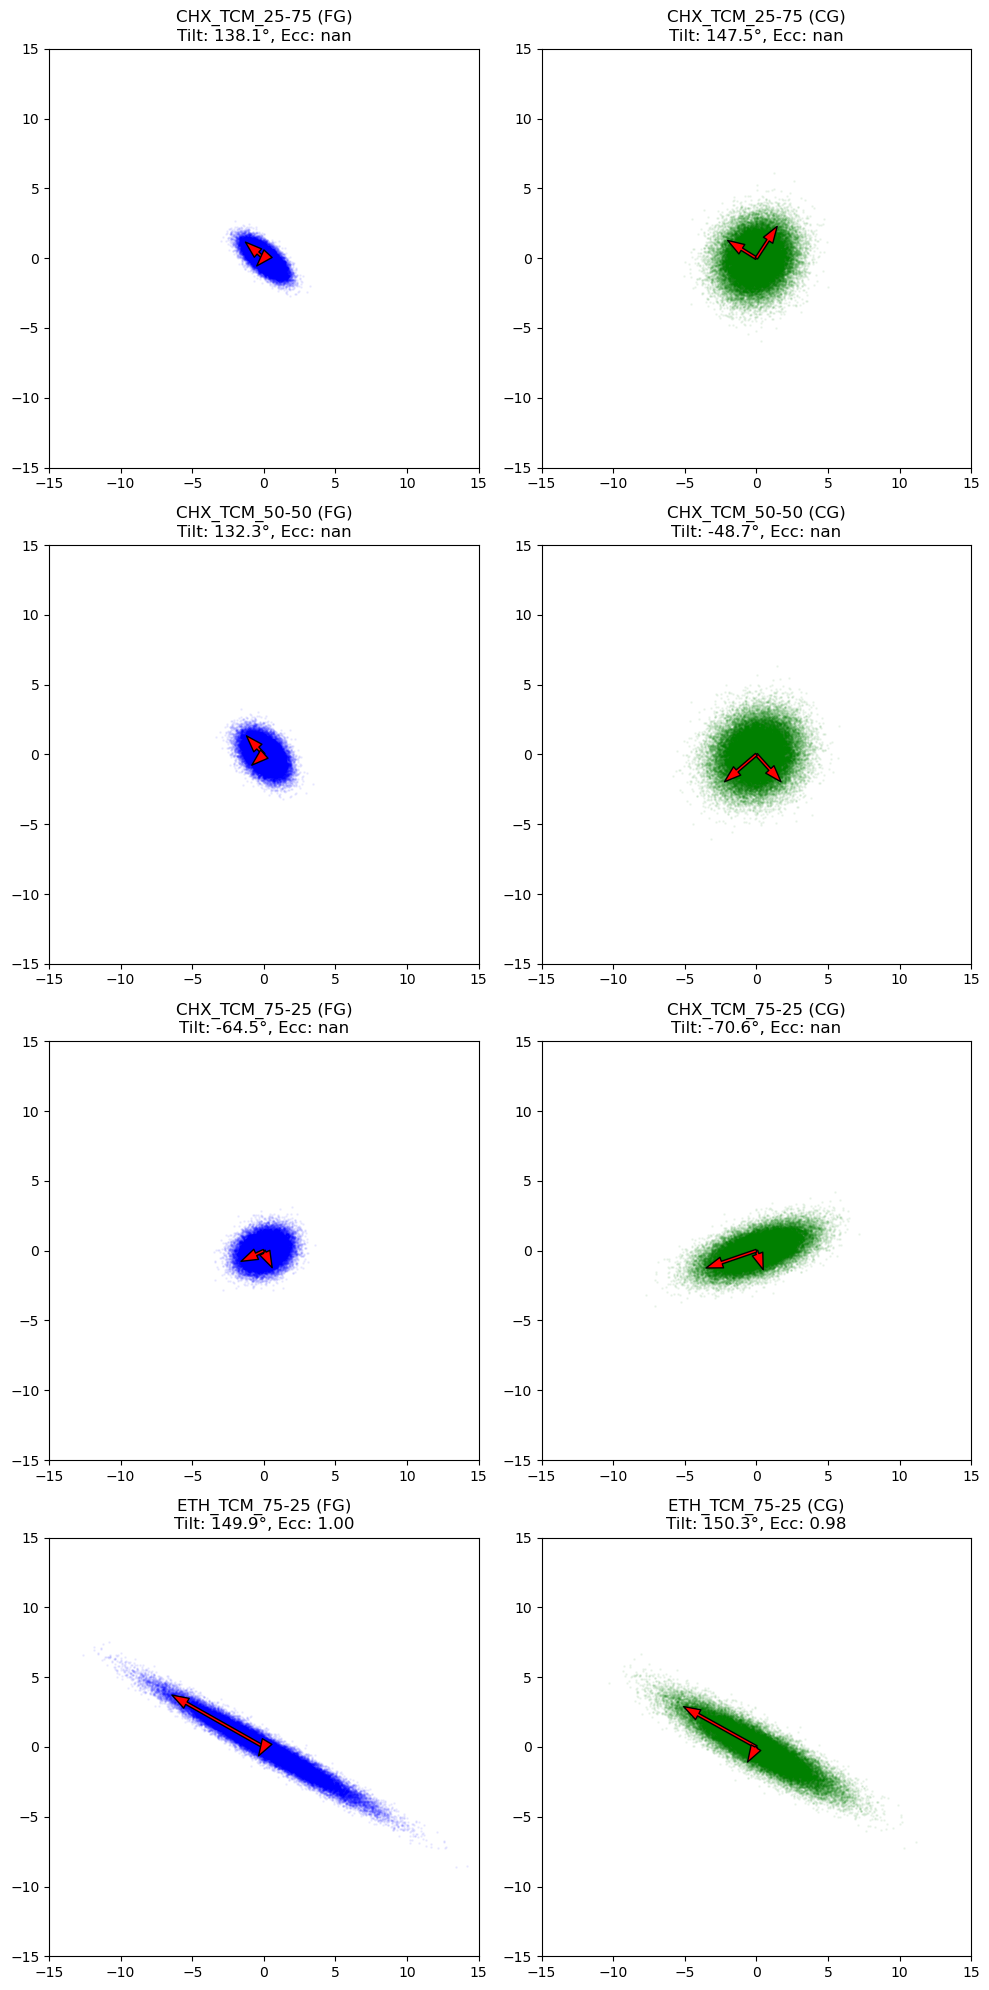

In [3]:
def plot_ellipses(ax, points, title, color):
    ax.scatter(points[:, 0], points[:, 1], s=1, color=color, alpha=0.05)
    ax.set_title(title, fontsize=12)
    ax.set_xlim(-15, 15)
    ax.set_ylim(-15, 15)

fig, axes = plt.subplots(len(mixtures), 2, figsize=(10, 5 * len(mixtures)))

for idx, mix in enumerate(mixtures):
    base_dir = os.path.join(data_root, mix, 'data_files', 'RDFs')
    
    rho_1, rho_2, comp1, comp2 = parse_system_density(mix)
    
    for col, model_type in enumerate(['FG', 'CG']):
        ax = axes[idx, col]
        
        try:
            # Load RDFs
            r, g11 = read_xvg(os.path.join(base_dir, f'rdf_{model_type}_{comp1}-{comp1}.xvg'))
            _, g22 = read_xvg(os.path.join(base_dir, f'rdf_{model_type}_{comp2}-{comp2}.xvg'))
            _, g12 = read_xvg(os.path.join(base_dir, f'rdf_{model_type}_{comp1}-{comp2}.xvg'))
            
            # Calculate KBI
            G11 = calc_kbi(r, g11)
            G22 = calc_kbi(r, g22)
            G12 = calc_kbi(r, g12)
            
            # Fluctuation Matrix
            fluct = FluctuationMatrix(rho_1, rho_2).fit(G11, G22, G12)
            S_mat = fluct.results['S_matrix']
            
            # Analysis
            analyzer = EllipseAnalyzer().fit(S_mat)
            
            # Sample points
            np.random.seed(42)
            points = np.random.multivariate_normal([0, 0], S_mat, 50000)
            
            # Plot
            plot_ellipses(ax, points, f"{mix} ({model_type})\nTilt: {analyzer.results['tilt_angle_degrees']:.1f}°, Ecc: {analyzer.results['eccentricity']:.2f}", 
                          "blue" if model_type == 'FG' else "green")
                          
            # Draw Arrows
            for j in range(2):
                vec = analyzer.results['eigenvectors'][:, j] * np.sqrt(np.abs(analyzer.results['eigenvalues'][j])) * 2
                ax.annotate("", xy=vec, xytext=(0, 0), arrowprops=dict(facecolor="red", width=2, headwidth=8), zorder=5)
                
        except Exception as e:
            ax.set_title(f"{mix} ({model_type}) - Error / Not PSD")
            print(f"Error processing {mix} {model_type}: {e}")

plt.tight_layout()
plt.savefig("fg_cg_fluctuation_comparison.png", dpi=300, facecolor='white')
plt.show()


## Observations
1. **Ideal vs. Non-Ideal (FG)**: Compare the `ETH_TCM` mixture with the `CHX_TCM` ideal mixtures. Notice how the clustering/non-ideality in ethanol mixtures affects the tilt and spread of the ellipse compared to standard excluded volume effects in ideal mixtures.
2. **FG vs. CG consistency**: The ultimate test of the CG model is whether the green ellipses (CG) accurately match the blue ellipses (FG). If they match, the CG model has successfully preserved the macroscopic thermodynamics (concentration fluctuations) of the underlying atomistic system!


/Users/yyangg00/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/yyangg00/opt/anaconda3/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


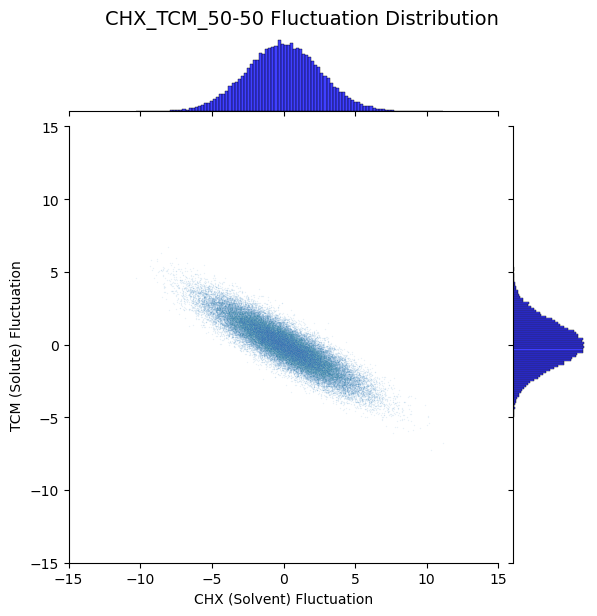

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# 1. Convert data to Pandas DataFrame (for axis labeling)
# Assign Solute/Solvent labels based on the majority component
system = "CHX_TCM_50-50"

current_params = system_params[system]
if current_params['N1'] >= current_params['N2']:
    x_label = f"{current_params['comp1']} (Solvent) Fluctuation"
    y_label = f"{current_params['comp2']} (Solute) Fluctuation"
else:
    x_label = f"{current_params['comp1']} (Solute) Fluctuation"
    y_label = f"{current_params['comp2']} (Solvent) Fluctuation"

df_points = pd.DataFrame(points, columns=[x_label, y_label])

# 2. Plot Seaborn Jointplot (scatter in the center, 1D Gaussians on the margins)
g = sns.jointplot(
    data=df_points, 
    x=x_label, 
    y=y_label, 
    kind="scatter", 
    alpha=0.1, 
    s=1,
    marginal_kws=dict(bins=100, fill=True, color='b') # Marginal histogram settings
)

# 3. Configure plot aesthetics (unified axis limits and title)
g.ax_joint.set_xlim(-15, 15)
g.ax_joint.set_ylim(-15, 15)
g.fig.suptitle(f"{system} Fluctuation Distribution", y=1.02, fontsize=14)
g.fig.savefig(f"{system}.png")
plt.show()


In [ ]:
from kb_fluct import summarize_results
from IPython.display import display

# Summarize all parameters into a nice pandas DataFrame
summary_df = summarize_results(fluct, analyzer, dist_analyzer)
display(summary_df)